In [4]:
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

# Load data
df = pd.read_csv("../data/reddit_posts.csv")

# Basic info
print("Shape:", df.shape)

Shape: (1492, 11)


In [5]:
print("\nColumns:", df.columns.tolist())


Columns: ['subreddit', 'title', 'score', 'upvote_ratio', 'num_comments', 'created_utc', 'author', 'url', 'is_self', 'num_crossposts', 'upvotes']


In [8]:
print("Data Types:")
df.dtypes

Data Types:


subreddit             str
title                 str
score               int64
upvote_ratio      float64
num_comments        int64
created_utc           str
author                str
url                   str
is_self              bool
num_crossposts      int64
upvotes             int64
dtype: object

In [10]:
df.head()

,subreddit,title,score,upvote_ratio,num_comments,created_utc,author,url,is_self,num_crossposts,upvotes
0,technology,DOJ Deletes Study Showing Domestic Terrorists ...,118005,0.88,2681,2025-09-16 16:44:54,Wagamaga,https://www.404media.co/doj-deletes-study-show...,False,28,118005
1,technology,Disney+ cancellation page crashes as customers...,99085,0.89,3300,2025-09-20 00:15:30,[deleted],https://creators.yahoo.com/lifestyle/story/dis...,False,11,99085
2,technology,"Yes, Jimmy Kimmel’s suspension was government ...",97126,0.81,3102,2025-09-18 21:39:46,Valinaut,https://www.theverge.com/policy/781148/jimmy-k...,False,14,97126
3,technology,Bernie Sanders says that if AI makes us so pro...,88659,0.94,2067,2025-06-25 16:25:43,a_Ninja_b0y,https://techcrunch.com/2025/06/25/bernie-sande...,False,8,88659
4,technology,Disney reportedly lost 1.7 million paid subscr...,85114,0.91,3252,2025-09-29 20:38:49,MarvelsGrantMan136,https://www.engadget.com/entertainment/streami...,False,8,85114


In [12]:
# Missing values
print("Missing Values:\n")
df.isnull().sum()

Missing Values:



subreddit         0
title             0
score             0
upvote_ratio      0
num_comments      0
created_utc       0
author            0
url               0
is_self           0
num_crossposts    0
upvotes           0
dtype: int64

In [19]:
# Duplicates
print("\nDuplicate rows:")
df.duplicated().sum()


Duplicate rows:


np.int64(0)

In [14]:
# Score distribution
print("\nScore stats:\n")
df["score"].describe()


Score stats:



count      1492.000000
mean      10935.975871
std       16755.334811
min          49.000000
25%         155.750000
50%         554.000000
75%       22577.250000
max      118005.000000
Name: score, dtype: float64

In [15]:
# Posts per subreddit
print("\nPosts per subreddit:\n")
df["subreddit"].value_counts()


Posts per subreddit:



subreddit
programming        498
technology         497
MachineLearning    497
Name: count, dtype: int64

In [20]:
# Fix datetime column
df["created_utc"] = pd.to_datetime(df["created_utc"])

Cleaned shape: (1492, 17)

New columns added: ['hour', 'day_of_week', 'month', 'title_word_count', 'title_char_count', 'engagement_ratio', 'is_viral']

Viral posts: 373
Non-viral posts: 1119

Virality threshold score: 22577.25

Sample row:
 subreddit                                                  technology
title               DOJ Deletes Study Showing Domestic Terrorists ...
score                                                          118005
upvote_ratio                                                     0.88
num_comments                                                     2681
created_utc                                       2025-09-16 16:44:54
author                                                       Wagamaga
url                 https://www.404media.co/doj-deletes-study-show...
is_self                                                         False
num_crossposts                                                     28
hour                                                       

In [ ]:
# Drop duplicate 'upvotes' column (same as score)
df = df.drop(columns=["upvotes"])

In [ ]:
# Extract useful time features
df["hour"] = df["created_utc"].dt.hour
df["day_of_week"] = df["created_utc"].dt.day_name()
df["month"] = df["created_utc"].dt.month_name()

In [ ]:
# Title length in words
df["title_word_count"] = df["title"].apply(lambda x: len(x.split()))

In [ ]:
# Title length in characters
df["title_char_count"] = df["title"].apply(lambda x: len(x))

In [ ]:
# Engagement ratio (comments per upvote - measures discussion intensity)
df["engagement_ratio"] = df["num_comments"] / (df["score"] + 1)

In [ ]:
# Virality label - top 25% posts = viral, bottom 75% = not viral
threshold = df["score"].quantile(0.75)
df["is_viral"] = df["score"] >= threshold

In [ ]:
print("Cleaned shape:", df.shape)
print("\nNew columns added:", ["hour", "day_of_week", "month", "title_word_count", "title_char_count", "engagement_ratio", "is_viral"])
print("\nViral posts:", df["is_viral"].sum())
print("Non-viral posts:", (~df["is_viral"]).sum())
print("\nVirality threshold score:", threshold)
print("\nSample row:\n", df.iloc[0])

In [7]:
df.to_csv("../data/reddit_posts_clean.csv", index=False)
print("Cleaned data saved.")

Cleaned data saved.


In [8]:
# Set visual style
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 5)

# Average score per subreddit
subreddit_stats = df.groupby("subreddit").agg(
    avg_score=("score", "mean"),
    avg_comments=("num_comments", "mean"),
    avg_upvote_ratio=("upvote_ratio", "mean"),
    avg_engagement=("engagement_ratio", "mean"),
    total_posts=("score", "count")
).round(2)

print(subreddit_stats)

                 avg_score  avg_comments  avg_upvote_ratio  avg_engagement  \
subreddit                                                                    
MachineLearning     134.56         56.28              0.92            0.50   
programming         778.22        192.41              0.92            0.28   
technology        31915.58       1539.40              0.95            0.05   

                 total_posts  
subreddit                     
MachineLearning          497  
programming              498  
technology               497  


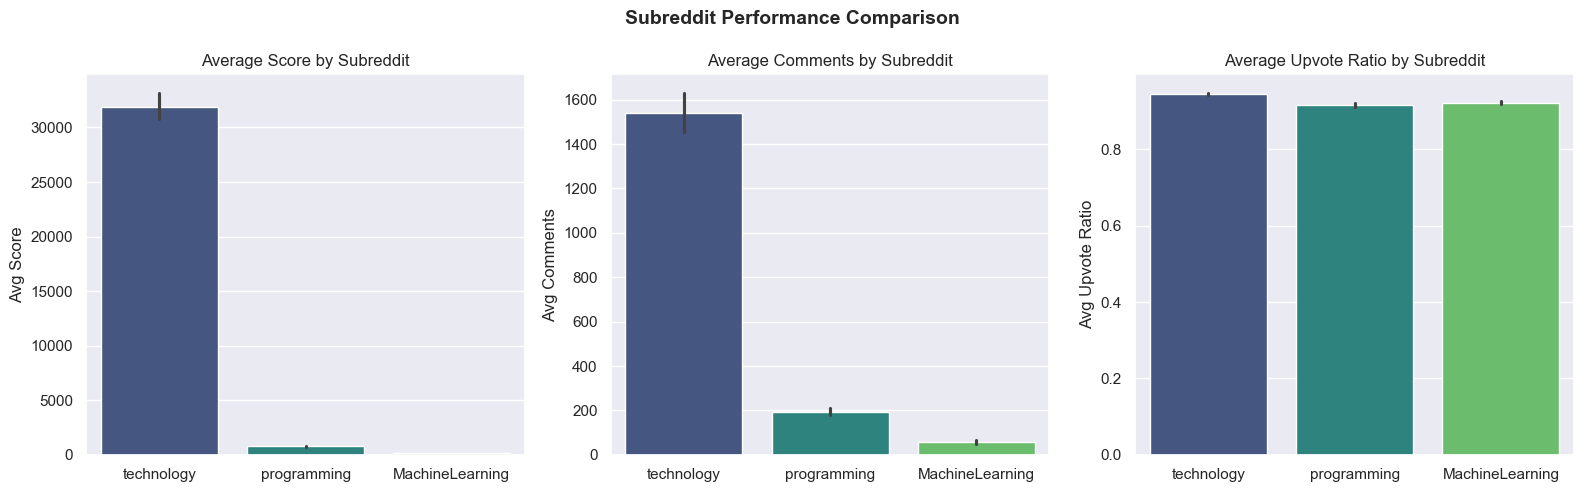

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Average Score
sns.barplot(data=df, x="subreddit", y="score", estimator="mean", ax=axes[0], palette="viridis")
axes[0].set_title("Average Score by Subreddit")
axes[0].set_xlabel("")
axes[0].set_ylabel("Avg Score")

# Average Comments
sns.barplot(data=df, x="subreddit", y="num_comments", estimator="mean", ax=axes[1], palette="viridis")
axes[1].set_title("Average Comments by Subreddit")
axes[1].set_xlabel("")
axes[1].set_ylabel("Avg Comments")

# Average Upvote Ratio
sns.barplot(data=df, x="subreddit", y="upvote_ratio", estimator="mean", ax=axes[2], palette="viridis")
axes[2].set_title("Average Upvote Ratio by Subreddit")
axes[2].set_xlabel("")
axes[2].set_ylabel("Avg Upvote Ratio")

plt.suptitle("Subreddit Performance Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../data/subreddit_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

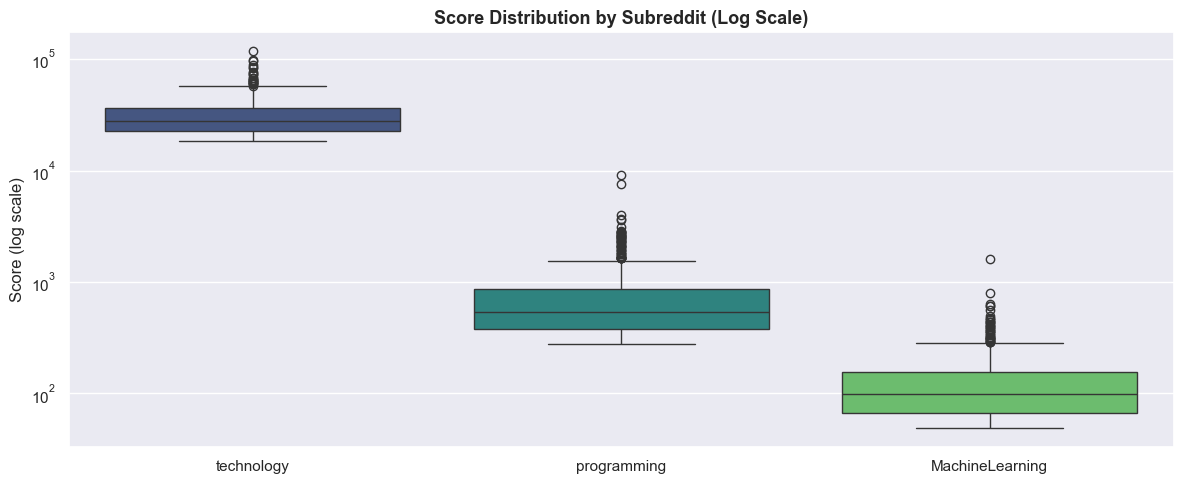

In [10]:
plt.figure(figsize=(12, 5))

sns.boxplot(data=df, x="subreddit", y="score", palette="viridis")
plt.yscale("log")  # Log scale because scores vary wildly
plt.title("Score Distribution by Subreddit (Log Scale)", fontsize=13, fontweight="bold")
plt.xlabel("")
plt.ylabel("Score (log scale)")
plt.tight_layout()
plt.savefig("../data/score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

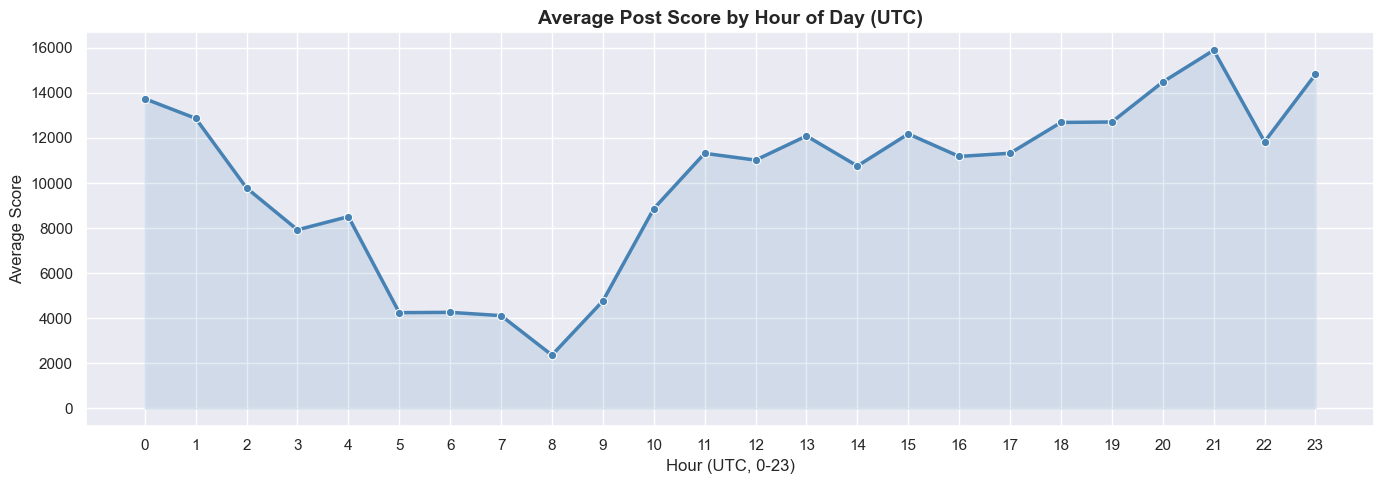

Top 5 best hours to post:
    hour     avg_score
21    21  15894.934426
23    23  14825.674419
20    20  14484.827160
0      0  13742.923077
1      1  12871.190476


In [11]:
# Average score by hour of day
hourly = df.groupby("hour")["score"].mean().reset_index()
hourly.columns = ["hour", "avg_score"]

plt.figure(figsize=(14, 5))
sns.lineplot(data=hourly, x="hour", y="avg_score", marker="o", color="steelblue", linewidth=2.5)
plt.fill_between(hourly["hour"], hourly["avg_score"], alpha=0.15, color="steelblue")
plt.title("Average Post Score by Hour of Day (UTC)", fontsize=14, fontweight="bold")
plt.xlabel("Hour (UTC, 0-23)")
plt.ylabel("Average Score")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.savefig("../data/score_by_hour.png", dpi=150, bbox_inches="tight")
plt.show()

# Print top 5 best hours
print("Top 5 best hours to post:")
print(hourly.sort_values("avg_score", ascending=False).head())

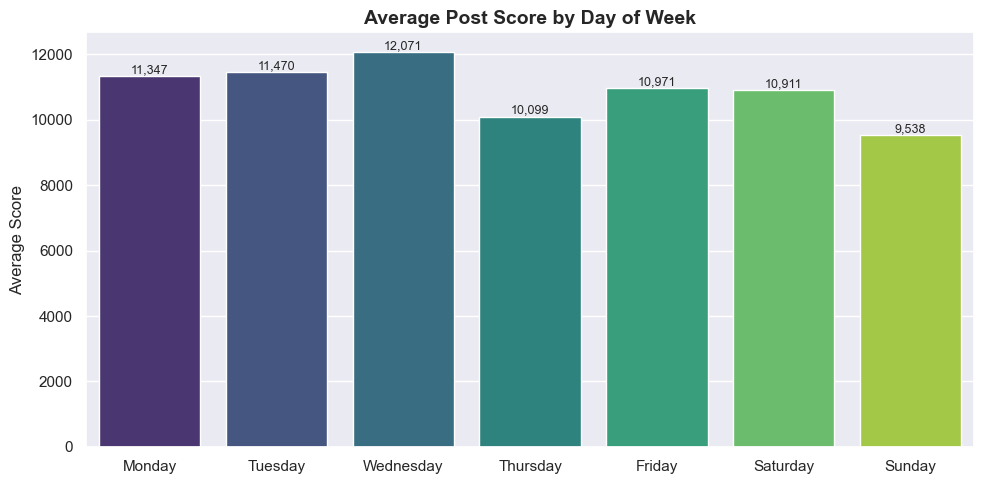


Days ranked by average score:
      day    avg_score
Wednesday 12070.928270
  Tuesday 11469.848739
   Monday 11346.660099
   Friday 10970.974093
 Saturday 10910.546448
 Thursday 10099.000000
   Sunday  9538.414634


In [12]:
# Define correct day order
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Average score by day
daily = df.groupby("day_of_week")["score"].mean().reindex(day_order).reset_index()
daily.columns = ["day", "avg_score"]

plt.figure(figsize=(10, 5))
bars = sns.barplot(data=daily, x="day", y="avg_score", palette="viridis")
plt.title("Average Post Score by Day of Week", fontsize=14, fontweight="bold")
plt.xlabel("")
plt.ylabel("Average Score")

# Add value labels on top of each bar
for bar, val in zip(bars.patches, daily["avg_score"]):
    bars.annotate(f"{val:,.0f}",
                  (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                  ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("../data/score_by_day.png", dpi=150, bbox_inches="tight")
plt.show()

# Print ranked days
print("\nDays ranked by average score:")
print(daily.sort_values("avg_score", ascending=False).to_string(index=False))

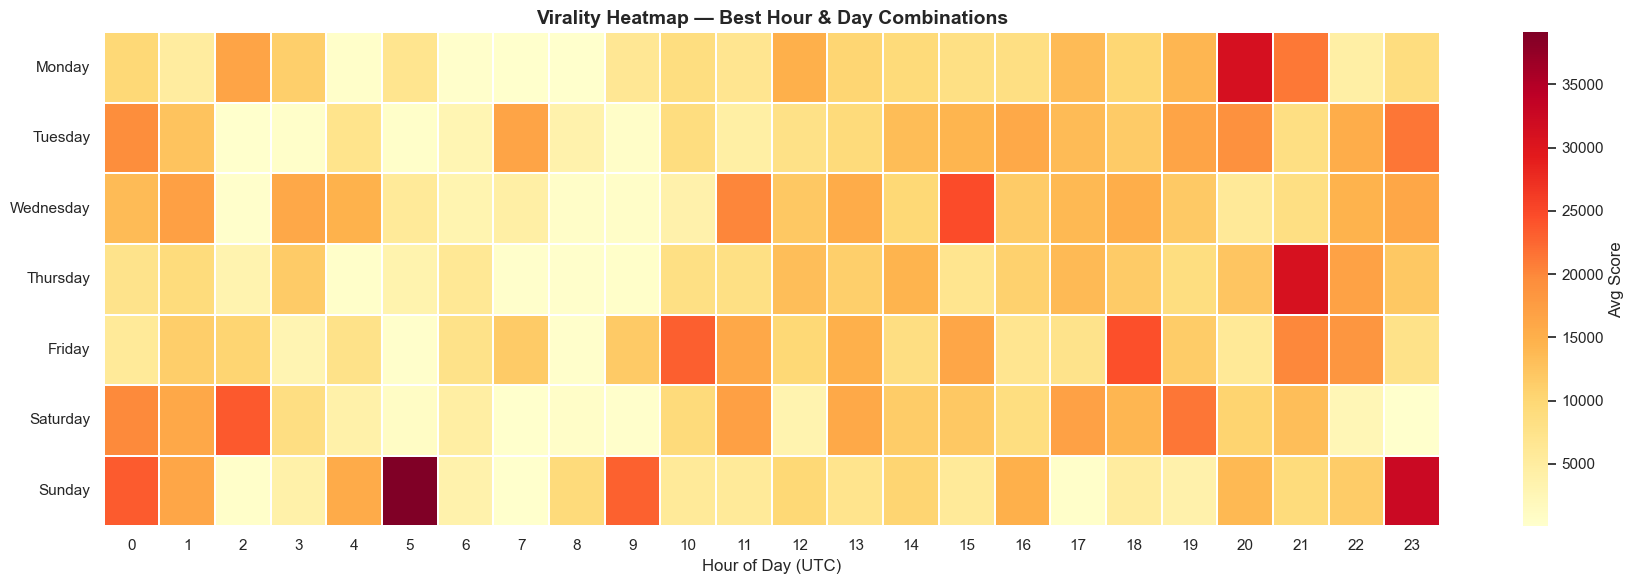

In [13]:
# Pivot table - average score for each hour+day combination
pivot = df.pivot_table(values="score", index="day_of_week", columns="hour", aggfunc="mean")
pivot = pivot.reindex(day_order)  # Correct day order

plt.figure(figsize=(18, 6))
sns.heatmap(
    pivot,
    cmap="YlOrRd",
    linewidths=0.3,
    annot=False,
    fmt=".0f",
    cbar_kws={"label": "Avg Score"}
)
plt.title("Virality Heatmap — Best Hour & Day Combinations", fontsize=14, fontweight="bold")
plt.xlabel("Hour of Day (UTC)")
plt.ylabel("")
plt.tight_layout()
plt.savefig("../data/heatmap_hour_day.png", dpi=150, bbox_inches="tight")
plt.show()

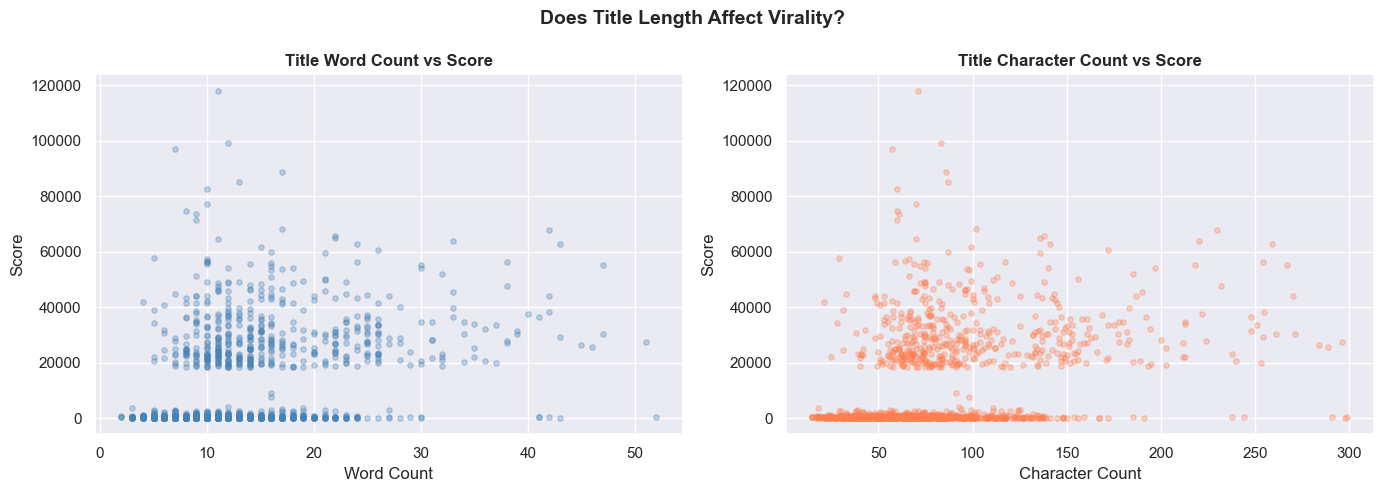

Correlation — Word Count vs Score: 0.375
Correlation — Char Count vs Score: 0.384


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Word count vs score
axes[0].scatter(df["title_word_count"], df["score"], alpha=0.3, color="steelblue", s=15)
axes[0].set_title("Title Word Count vs Score", fontweight="bold")
axes[0].set_xlabel("Word Count")
axes[0].set_ylabel("Score")

# Char count vs score
axes[1].scatter(df["title_char_count"], df["score"], alpha=0.3, color="coral", s=15)
axes[1].set_title("Title Character Count vs Score", fontweight="bold")
axes[1].set_xlabel("Character Count")
axes[1].set_ylabel("Score")

plt.suptitle("Does Title Length Affect Virality?", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../data/title_length_vs_score.png", dpi=150, bbox_inches="tight")
plt.show()

# Correlation values
word_corr = df["title_word_count"].corr(df["score"])
char_corr = df["title_char_count"].corr(df["score"])
print(f"Correlation — Word Count vs Score: {word_corr:.3f}")
print(f"Correlation — Char Count vs Score: {char_corr:.3f}")

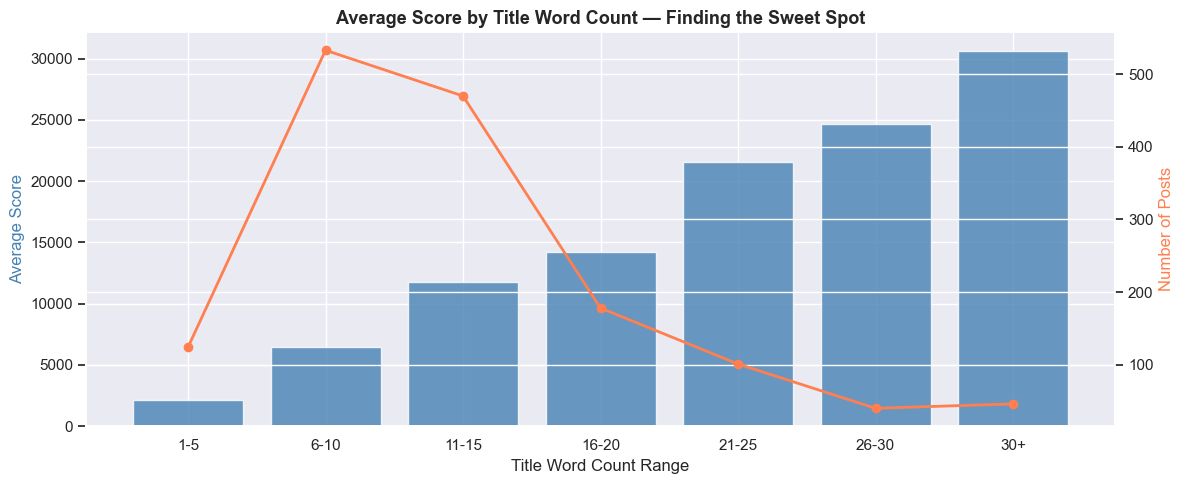


Word bucket stats:
word_bucket    avg_score  post_count
        1-5  2139.774194         124
       6-10  6423.634146         533
      11-15 11759.808511         470
      16-20 14212.983146         178
      21-25 21541.683168         101
      26-30 24648.750000          40
        30+ 30623.173913          46


In [15]:
# Bin posts by word count into buckets
df["word_bucket"] = pd.cut(
    df["title_word_count"],
    bins=[0, 5, 10, 15, 20, 25, 30, 100],
    labels=["1-5", "6-10", "11-15", "16-20", "21-25", "26-30", "30+"]
)

# Average score per bucket
bucket_stats = df.groupby("word_bucket", observed=True)["score"].agg(["mean", "count"]).reset_index()
bucket_stats.columns = ["word_bucket", "avg_score", "post_count"]

fig, ax1 = plt.subplots(figsize=(12, 5))

# Bar chart for avg score
bars = ax1.bar(bucket_stats["word_bucket"], bucket_stats["avg_score"],
               color="steelblue", alpha=0.8, label="Avg Score")
ax1.set_ylabel("Average Score", color="steelblue")
ax1.set_xlabel("Title Word Count Range")
ax1.set_title("Average Score by Title Word Count — Finding the Sweet Spot",
              fontweight="bold", fontsize=13)

# Overlay line for post count
ax2 = ax1.twinx()
ax2.plot(bucket_stats["word_bucket"], bucket_stats["post_count"],
         color="coral", marker="o", linewidth=2, label="Post Count")
ax2.set_ylabel("Number of Posts", color="coral")

plt.tight_layout()
plt.savefig("../data/word_bucket_score.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nWord bucket stats:")
print(bucket_stats.to_string(index=False))

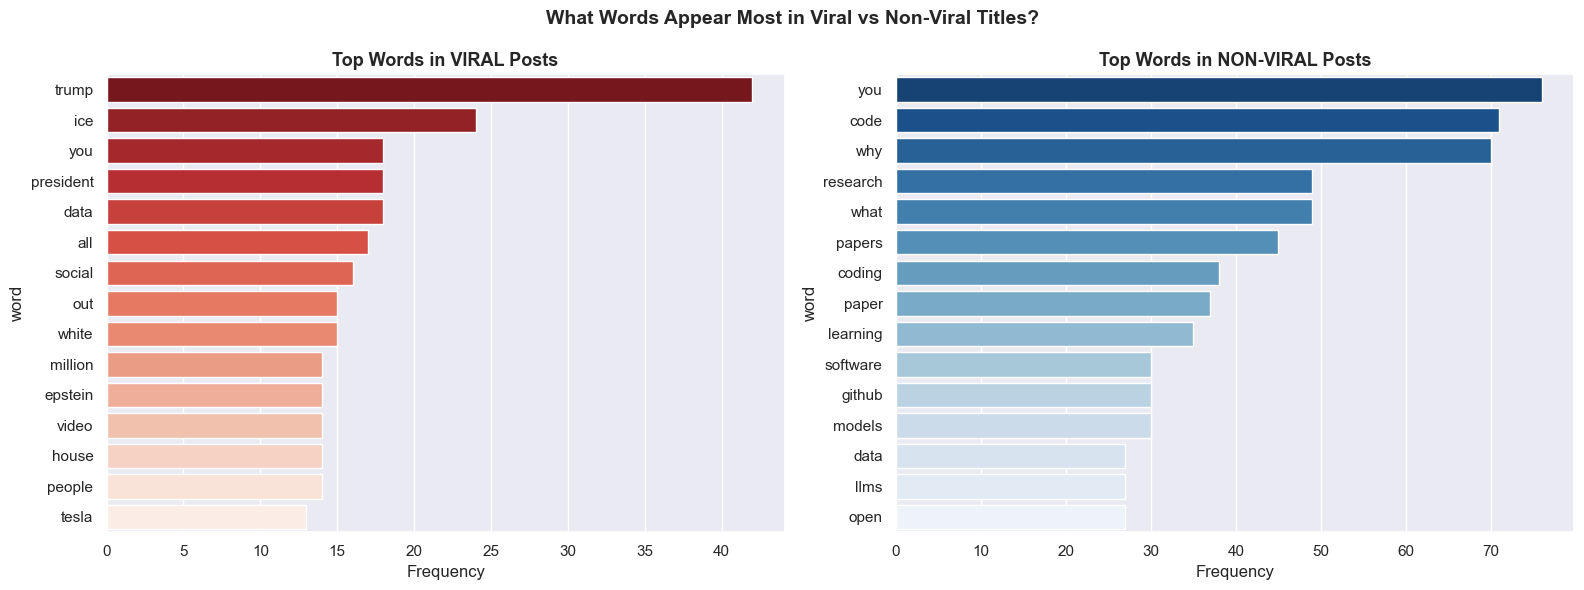


Top 15 Viral words:
     word  count
    trump     42
      ice     24
      you     18
president     18
     data     18
      all     17
   social     16
      out     15
    white     15
  million     14
  epstein     14
    video     14
    house     14
   people     14
    tesla     13

Top 15 Non-Viral words:
    word  count
     you     76
    code     71
     why     70
research     49
    what     49
  papers     45
  coding     38
   paper     37
learning     35
software     30
  github     30
  models     30
    data     27
    llms     27
    open     27


In [16]:
from collections import Counter
import re

def get_words(titles):
    """Extract cleaned words from a list of titles."""
    stopwords = {
        "the", "a", "an", "and", "or", "but", "in", "on", "at", "to",
        "for", "of", "with", "is", "it", "as", "by", "from", "that",
        "this", "are", "was", "be", "have", "has", "not", "its", "will",
        "your", "their", "our", "about", "after", "over", "than", "up",
        "can", "new", "more", "into", "says", "would", "how", "his", "her"
    }
    words = []
    for title in titles:
        cleaned = re.sub(r"[^a-zA-Z\s]", "", title.lower())
        words.extend([w for w in cleaned.split() if w not in stopwords and len(w) > 2])
    return Counter(words)

# Split viral vs non-viral
viral_titles = df[df["is_viral"] == True]["title"]
nonviral_titles = df[df["is_viral"] == False]["title"]

viral_words = get_words(viral_titles)
nonviral_words = get_words(nonviral_titles)

# Top 15 words
viral_top = pd.DataFrame(viral_words.most_common(15), columns=["word", "count"])
nonviral_top = pd.DataFrame(nonviral_words.most_common(15), columns=["word", "count"])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=viral_top, x="count", y="word", ax=axes[0], palette="Reds_r")
axes[0].set_title("Top Words in VIRAL Posts", fontweight="bold", fontsize=13)
axes[0].set_xlabel("Frequency")

sns.barplot(data=nonviral_top, x="count", y="word", ax=axes[1], palette="Blues_r")
axes[1].set_title("Top Words in NON-VIRAL Posts", fontweight="bold", fontsize=13)
axes[1].set_xlabel("Frequency")

plt.suptitle("What Words Appear Most in Viral vs Non-Viral Titles?", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../data/viral_words.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 15 Viral words:")
print(viral_top.to_string(index=False))
print("\nTop 15 Non-Viral words:")
print(nonviral_top.to_string(index=False))

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import numpy as np

# --- Feature Engineering ---

# Encode categorical columns numerically
le_sub = LabelEncoder()
le_day = LabelEncoder()

df["subreddit_encoded"] = le_sub.fit_transform(df["subreddit"])
df["day_encoded"] = le_day.fit_transform(df["day_of_week"])

# Features we use to predict virality
features = [
    "subreddit_encoded",  # which subreddit
    "hour",               # what hour posted
    "day_encoded",        # what day posted
    "title_word_count",   # how many words in title
    "title_char_count",   # how many characters in title
    "num_crossposts",     # how many times crossposted
]

X = df[features]
y = df["is_viral"].astype(int)  # 1 = viral, 0 = not viral

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Viral posts in test set:", y_test.sum())
print("Non-viral posts in test set:", (y_test == 0).sum())
print("\nFeatures used:", features)

Training samples: 1193
Testing samples: 299
Viral posts in test set: 75
Non-viral posts in test set: 224

Features used: ['subreddit_encoded', 'hour', 'day_encoded', 'title_word_count', 'title_char_count', 'num_crossposts']


In [18]:
# Define 3 models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Score
    auc = roc_auc_score(y_test, y_prob)
    results[name] = {
        "model": model,
        "y_pred": y_pred,
        "auc": auc
    }
    
    print(f"\n{'='*45}")
    print(f"Model: {name}")
    print(f"AUC Score: {auc:.3f}")
    print(classification_report(y_test, y_pred, target_names=["Not Viral", "Viral"]))


Model: Logistic Regression
AUC Score: 0.968
              precision    recall  f1-score   support

   Not Viral       0.99      0.92      0.95       224
       Viral       0.79      0.97      0.87        75

    accuracy                           0.93       299
   macro avg       0.89      0.94      0.91       299
weighted avg       0.94      0.93      0.93       299


Model: Random Forest
AUC Score: 0.962
              precision    recall  f1-score   support

   Not Viral       0.96      0.92      0.94       224
       Viral       0.80      0.88      0.84        75

    accuracy                           0.91       299
   macro avg       0.88      0.90      0.89       299
weighted avg       0.92      0.91      0.91       299


Model: Gradient Boosting
AUC Score: 0.958
              precision    recall  f1-score   support

   Not Viral       0.96      0.92      0.94       224
       Viral       0.78      0.89      0.83        75

    accuracy                           0.91       299
 

Best Model: Logistic Regression (AUC: 0.968)



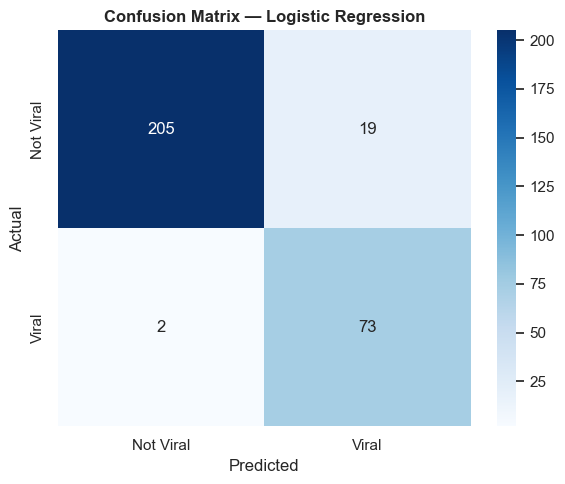

In [19]:
# Get best model by AUC
best_name = max(results, key=lambda x: results[x]["auc"])
best_model = results[best_name]["model"]
print(f"Best Model: {best_name} (AUC: {results[best_name]['auc']:.3f})\n")

# Feature importance (works for tree-based models)
if hasattr(best_model, "feature_importances_"):
    importance_df = pd.DataFrame({
        "feature": features,
        "importance": best_model.feature_importances_
    }).sort_values("importance", ascending=True)

    plt.figure(figsize=(10, 5))
    bars = plt.barh(importance_df["feature"], importance_df["importance"],
                    color="steelblue", edgecolor="white")
    plt.title(f"Feature Importance — {best_name}", fontsize=13, fontweight="bold")
    plt.xlabel("Importance Score")

    # Add value labels
    for bar, val in zip(bars, importance_df["importance"]):
        plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                 f"{val:.3f}", va="center", fontsize=10)

    plt.tight_layout()
    plt.savefig("../data/feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()

# Confusion matrix
y_pred_best = results[best_name]["y_pred"]
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Viral", "Viral"],
            yticklabels=["Not Viral", "Viral"])
plt.title(f"Confusion Matrix — {best_name}", fontweight="bold")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("../data/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [20]:
# If feature importance chart didn't show, run this
print("\nFeature Importance from Random Forest:")
importance_df2 = pd.DataFrame({
    "feature": features,
    "importance": results["Random Forest"]["model"].feature_importances_
}).sort_values("importance", ascending=False)
print(importance_df2.to_string(index=False))


Feature Importance from Random Forest:
          feature  importance
subreddit_encoded    0.400620
   num_crossposts    0.287128
 title_char_count    0.116581
 title_word_count    0.076270
             hour    0.074446
      day_encoded    0.044954
